# EDA Correlations - Feature correlation analysis

This notebook builds basic numeric features from TimescaleDB transaction data,
computes the Pearson correlation matrix, obtains feature importances from a simple model,
and identifies redundant features and candidates for removal.

## Setup

In [1]:
import os
import socket

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

load_dotenv()

TIMESCALE_HOST = os.getenv("TIMESCALE_HOST", "localhost")
TIMESCALE_PORT = int(os.getenv("TIMESCALE_PORT", "5433"))
TIMESCALE_USER = os.getenv("TIMESCALE_USER", "postgres")
TIMESCALE_PASSWORD = os.getenv("TIMESCALE_PASSWORD", "postgres")
TIMESCALE_DB = os.getenv("TIMESCALE_DB", "timescaledb")

try:
    socket.getaddrinfo(TIMESCALE_HOST, TIMESCALE_PORT)
except socket.gaierror:
    TIMESCALE_HOST = "localhost"
    if TIMESCALE_PORT == 5432:
        TIMESCALE_PORT = 5433
    print("TimescaleDB host not resolvable. Using localhost.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

## Load data

In [2]:
def create_connection():
    return psycopg2.connect(
        host=TIMESCALE_HOST,
        port=TIMESCALE_PORT,
        user=TIMESCALE_USER,
        password=TIMESCALE_PASSWORD,
        dbname=TIMESCALE_DB,
    )


def load_transactions():
    query = """
        SELECT
            transaction_id,
            user_id,
            merchant_id,
            merchant_category,
            amount::double precision AS amount,
            country,
            device_type,
            ip_hash,
            timestamp,
            is_fraud,
            model_score,
            latency_ms
        FROM public.transactions
    """
    with create_connection() as connection:
        with connection.cursor() as cursor:
            cursor.execute(query)
            rows = cursor.fetchall()
            columns = [col[0] for col in cursor.description]
    return pd.DataFrame(rows, columns=columns)


transactions = load_transactions()
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], utc=True)
transactions["is_fraud"] = transactions["is_fraud"].astype(int)

print(f"Total transactions loaded: {len(transactions):,}")
print(f"Fraud: {transactions['is_fraud'].sum():,} ({transactions['is_fraud'].mean():.2%})")
transactions.head()

Total transactions loaded: 10,000
Fraud: 200 (2.00%)


,transaction_id,user_id,merchant_id,merchant_category,amount,country,device_type,ip_hash,timestamp,is_fraud,model_score,latency_ms
0,1a8ec7d3-9d72-550c-ab37-45af247b62b6,user_0142,merchant_0003,travel,483.47,BR,web,28d5516375e8f95247d08ecc978f096eaf25a30e68edf3...,2026-04-27 19:06:08+00:00,0,None,None
1,f7c00e5b-9074-5481-8e80-888bf1d3498e,user_0146,merchant_0036,retail,95.08,AR,web,e3b6646ebfb1e5b735b6dde50c6ab6cc645b44fe75187d...,2026-04-27 16:48:02+00:00,0,None,None
2,d99f5c89-0500-54c3-8b70-49fe1b84ae01,user_0146,merchant_0006,online,100.65,AR,web,3018db761be7a1023de11691084ddd6285270237781e0b...,2026-04-27 09:49:55+00:00,0,None,None
3,4301a172-b77c-52c1-b16a-fc14bc720055,user_0125,merchant_0030,food,31.08,AR,web,2d70b93d649bf811a45c483fd29d349c419ac97ce556a2...,2026-04-27 18:18:10+00:00,0,None,None
4,85523585-601d-53ac-918f-2e0e4e4f59a9,user_0030,merchant_0033,gas_station,34.05,AR,web,8f591dc226622fa5c69f285e178302c8d4dd249cccd52a...,2026-04-27 16:37:36+00:00,0,None,None


## Build numeric features

Minimum columns required for correlation analysis:
- **`hour_of_day`** and **`day_of_week`** extracted from `timestamp`
- **`amount`** as-is
- **`log_amount`**: natural log of `amount` (useful for skewed distributions)
- Ordinal encoding via `LabelEncoder` for categorical variables (`merchant_category`, `country`, `device_type`)
- **`is_fraud`** as 0/1

In [3]:
df = transactions.copy()

df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0=Monday, 6=Sunday

# clip to avoid log(0) or negative values
df["log_amount"] = np.log(df["amount"].clip(lower=1e-9))

le = LabelEncoder()
df["merchant_category_enc"] = le.fit_transform(df["merchant_category"].astype(str))
df["country_enc"] = le.fit_transform(df["country"].astype(str))
df["device_type_enc"] = le.fit_transform(df["device_type"].astype(str))

FEATURE_COLS = [
    "amount",
    "log_amount",
    "hour_of_day",
    "day_of_week",
    "merchant_category_enc",
    "country_enc",
    "device_type_enc",
    "is_fraud",
]

features_df = df[FEATURE_COLS].copy()
features_df.dtypes

amount                   float64
log_amount               float64
hour_of_day                int32
day_of_week                int32
merchant_category_enc      int64
country_enc                int64
device_type_enc            int64
is_fraud                   int64
dtype: object

In [4]:
features_df.describe().round(4)

,amount,log_amount,hour_of_day,day_of_week,merchant_category_enc,country_enc,device_type_enc,is_fraud
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.00
mean,151.8723,4.2380,14.7873,3.0350,3.0674,1.4690,0.7345,0.02
std,271.7434,1.1446,4.8450,1.9495,1.9773,3.3409,0.8653,0.14
min,4.0700,1.4036,0.0000,0.0000,0.0000,0.0000,0.0000,0.00
25%,29.9600,3.3999,12.0000,1.0000,1.0000,0.0000,0.0000,0.00
50%,57.3700,4.0495,15.0000,3.0000,3.0000,0.0000,0.0000,0.00
75%,130.8125,4.8738,19.0000,5.0000,5.0000,1.0000,2.0000,0.00
max,3651.3100,8.2028,23.0000,6.0000,6.0000,13.0000,2.0000,1.00


## Pearson correlation matrix

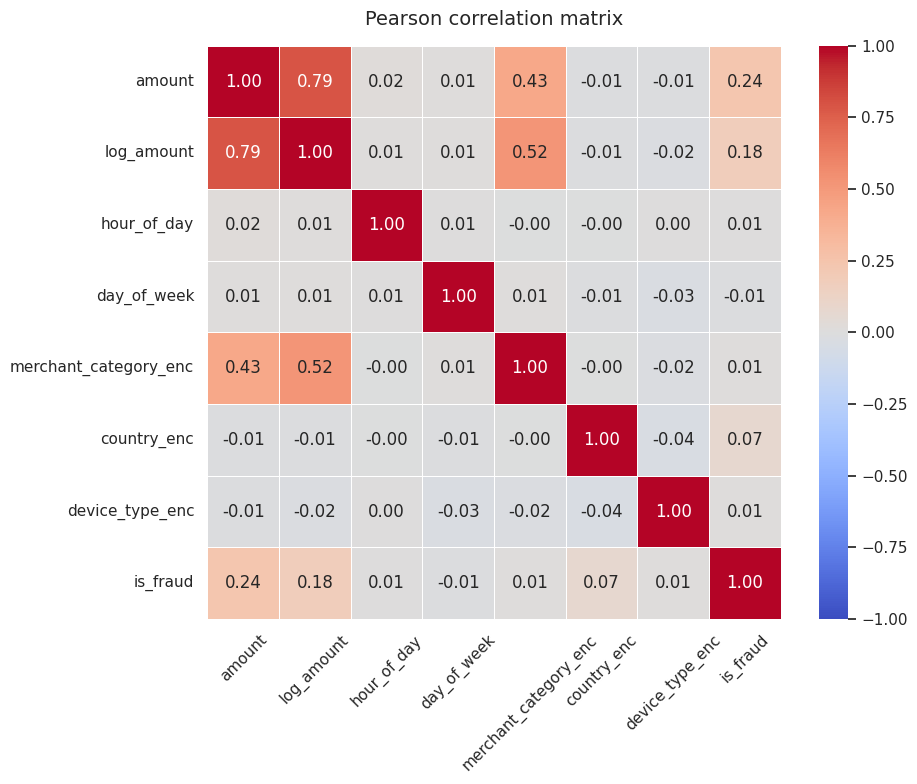

In [5]:
corr_matrix = features_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
)
ax.set_title("Pearson correlation matrix", fontsize=14, pad=15)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

Pearson correlation of each feature with is_fraud:
amount                   0.2393
log_amount               0.1793
country_enc              0.0715
day_of_week             -0.0125
merchant_category_enc    0.0110
device_type_enc          0.0083
hour_of_day              0.0072


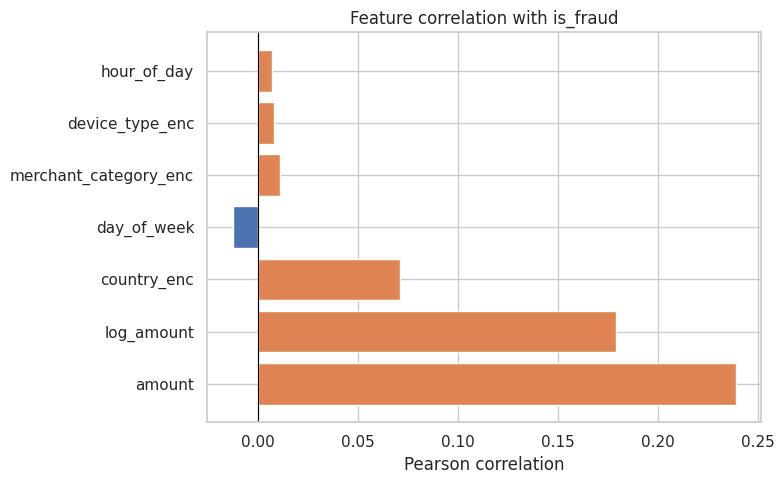

In [6]:
fraud_corr = corr_matrix["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)
print("Pearson correlation of each feature with is_fraud:")
print(fraud_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#dd8452" if v >= 0 else "#4c72b0" for v in fraud_corr.values]
ax.barh(fraud_corr.index, fraud_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation")
ax.set_title("Feature correlation with is_fraud")
plt.tight_layout()
plt.show()

## Feature importance — RandomForestClassifier

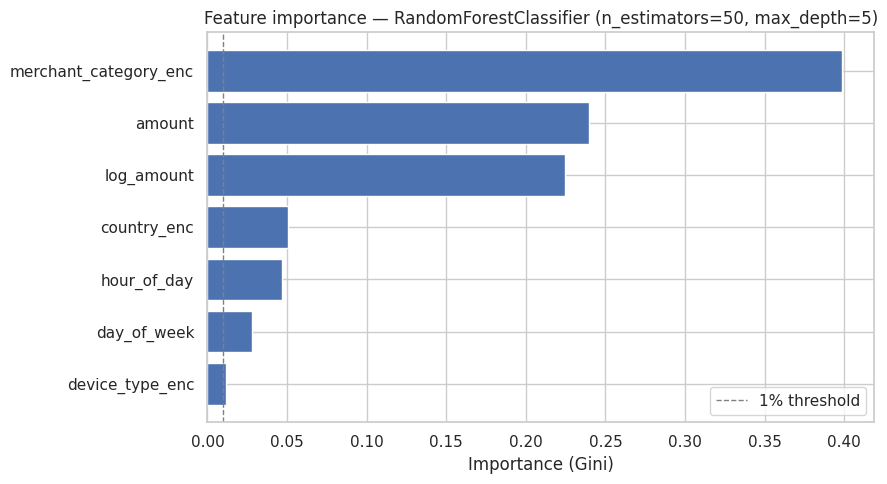


Importances (%):
merchant_category_enc    39.88
amount                   23.95
log_amount               22.49
country_enc               5.07
hour_of_day               4.67
day_of_week               2.80
device_type_enc           1.15


In [7]:
X_COLS = [c for c in FEATURE_COLS if c != "is_fraud"]
X = features_df[X_COLS].values
y = features_df["is_fraud"].values

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4c72b0" if v >= 0.01 else "#c44e52" for v in importances.values]
ax.barh(importances.index, importances.values, color=colors)
ax.axvline(0.01, color="gray", linestyle="--", linewidth=1, label="1% threshold")
ax.set_xlabel("Importance (Gini)")
ax.set_title("Feature importance — RandomForestClassifier (n_estimators=50, max_depth=5)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nImportances (%):")
print((importances * 100).round(2).sort_values(ascending=False).to_string())

## Redundant features and removal candidates

### Highly correlated pairs (|r| > 0.85)

In [8]:
REDUNDANCY_THRESHOLD = 0.85

corr_no_target = features_df[X_COLS].corr(method="pearson")
upper = corr_no_target.where(np.triu(np.ones(corr_no_target.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["correlation"].abs() > REDUNDANCY_THRESHOLD]
high_corr_pairs = high_corr_pairs.sort_values("correlation", key=abs, ascending=False)

if high_corr_pairs.empty:
    print(f"No pairs found with |correlation| > {REDUNDANCY_THRESHOLD}.")
else:
    print(f"Pairs with |correlation| > {REDUNDANCY_THRESHOLD}:")
    print(high_corr_pairs.to_string(index=False))

No pairs found with |correlation| > 0.85.


In [9]:
IMPORTANCE_THRESHOLD = 0.01

low_importance = importances[importances < IMPORTANCE_THRESHOLD]
print(f"Features with importance < {IMPORTANCE_THRESHOLD * 100:.0f}%:")
if low_importance.empty:
    print("  None.")
else:
    print((low_importance * 100).round(3).to_string())

Features with importance < 1%:
  None.


## Summary and conclusions

### Redundant features

If `amount` and `log_amount` show high correlation (|r| > 0.85), retain only `log_amount`
for the modeling pipeline as it better captures the log-normal distribution of transaction amounts.
The raw amount can still be used in descriptive analysis.

### Low-importance features

Features with importance < 1% according to the RandomForest are candidates for removal in the
feature engineering pipeline (task 4.2.x), though their behavior should be verified on real data
before dropping them definitively.

### Ordinal encoding

`merchant_category_enc`, `country_enc` and `device_type_enc` are arbitrary ordinal encodings
that do not preserve semantic order. Correlations with `is_fraud` for these variables should
be interpreted with caution — task 4.2.x will implement more appropriate encoding (e.g. frequency
or count encoding) for the final model.